In [1]:
"""
DATA ANALYSIS OF BIRD OBSERVATIONS DATA

To keep things simple, each cell computes just one visualization, and comment on top of cell is the summary. You must run this cell for mounting the drive, and the next cell for importing packages.

Variables:
df: raw dataframe, do not change
lat_long_df: contains lat and long coordinates of each observation
observationsDF (10k+ observations): dataframe with the following cols: udid  observationTime 	timeDiff	eclipseType	maxEclipse	timeSubmit	totalBegins	obscuration	flying	hear	perchedAlone	perchedOthers	sing	sitting	swimming	walking	other	eating	obscuration_bins	timeDiff_bins
filtered_observationsDF2 (6952 observations): observationsDF after filtering out observations made 4 hours before or after maxeclipse and averaging out duplicates

TODO:
"""

from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/Solarbird Data Stuff
!ls

Mounted at /content/drive
/content/drive/MyDrive/Solarbird Data Stuff
eclipseCurve.gsheet	   filtered_observations.csv  maxMagCoords.gdoc   Notes.gdoc
eclipse_explorer_flut.jsx  maxMagCoordsDown.gdoc      maxMagCoords.txt	  observations.csv
export2.csv		   maxMagCoordsDown.txt       maxMagCoordsUp.txt  solarbirdDataWork.ipynb


In [2]:
!pip install plotly # need plotly for map
!pip install pandas # need pandas for data preproc

import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Read the CSV file

df = pd.read_csv('export2.csv')
print(f"DF Columns: {df.columns}")
df

DF Columns: Index(['obscuration', 'birdSize', 'eating', 'eclipseBegins', 'eclipseEnds',
       'email', 'flying', 'hear', 'lat', 'long', 'maxEclipse', 'name', 'other',
       'perchedAlone', 'perchedOthers', 'practice', 'sing', 'sitting',
       'swimming', 'timeStart', 'timeSubmit', 'totalityBegins', 'totalityEnds',
       'udid', 'walking'],
      dtype='object')


,obscuration,birdSize,eating,eclipseBegins,eclipseEnds,email,flying,hear,lat,long,...,practice,sing,sitting,swimming,timeStart,timeSubmit,totalityBegins,totalityEnds,udid,walking
0,1.0,4,True,2024-04-08 13:50:00.000,2024-04-08 16:23:00.000,NaN,False,False,39.783416,-85.965242,...,False,False,True,False,2024-04-08 14:49:58.392666,2024-04-08 14:50:46.165985,2024-04-08 15:06:00.000,2024-04-08 15:10:00.000,feefb6bbf8ad63ed,False
1,1.0,1,True,2024-04-08 13:48:00.000,2024-04-08 16:22:00.000,jsheese@iu.edu,False,False,39.277133,-86.821038,...,False,False,False,False,2024-04-08 15:20:29.692853,2024-04-08 15:20:37.013972,2024-04-08 15:04:00.000,2024-04-08 15:08:00.000,9BCE8E1E-4804-4344-8ADC-7DFD394AE91C,False
2,1.0,2,False,2024-04-08 13:49:00.000,2024-04-08 16:22:00.000,luci@mckeanco.com,False,True,39.142583,-86.499955,...,False,True,False,False,2024-04-08 15:00:34.882184,2024-04-08 15:00:52.555641,2024-04-08 15:04:00.000,2024-04-08 15:08:00.000,f1a08bcbb23d9168,False
3,1.0,1,False,2024-04-08 12:14:00.000,2024-04-08 14:55:00.000,galaxycoff@yahoo.com,True,False,30.071580,-99.247638,...,False,False,False,False,2024-04-08 13:28:17.628223,2024-04-08 13:28:57.892744,2024-04-08 13:31:00.000,2024-04-08 13:36:00.000,19365862-6BE1-457A-947E-809F9F9C11EF,False
4,1.0,2,False,2024-04-08 13:58:00.000,2024-04-08 16:28:00.000,skengstrom@gmail.com,False,False,41.968613,-82.528407,...,False,False,True,False,2024-04-08 15:17:58.547586,2024-04-08 15:18:12.030083,2024-04-08 15:13:00.000,2024-04-08 15:16:00.000,67759611a2f8dd94,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10854,1.0,0,False,2024-04-08 13:52:00.000,2024-04-08 16:24:00.000,nishikiwillow @aol.com,False,True,40.267339,-85.423561,...,False,True,False,False,2024-04-08 14:49:55.501856,2024-04-08 14:50:38.056590,2024-04-08 15:07:00.000,2024-04-08 15:11:00.000,0863012E-243E-41C5-A756-498AF65622A3,False
10855,1.0,2,False,2024-04-08 14:00:00.000,2024-04-08 16:29:00.000,r55bb@sbcglobal.net,False,True,41.277322,-80.923965,...,False,False,False,False,2024-04-08 15:08:30.074869,2024-04-08 15:09:10.209472,2024-04-08 15:15:00.000,2024-04-08 15:17:00.000,9e186c42bfb0471b,False
10856,1.0,1,False,2024-04-08 13:49:00.000,2024-04-08 16:22:00.000,scottpletcher@purdue.edu,True,False,39.735742,-86.620109,...,False,False,False,False,2024-04-08 14:56:43.373344,2024-04-08 14:57:07.574607,2024-04-08 15:05:00.000,2024-04-08 15:08:00.000,88871BA6-7C02-40FC-8D63-7EF02AC40BEB,False
10857,1.0,2,False,2024-04-08 13:50:00.000,2024-04-08 16:23:00.000,ksmith47406@gmail.com,True,False,39.954498,-86.031079,...,False,True,False,False,2024-04-08 14:49:36.935768,2024-04-08 14:50:30.009644,2024-04-08 15:06:00.000,2024-04-08 15:10:00.000,cdee1e8d13441b96,False


In [4]:
# Info about observations df

print(f"Total observations: {len(df)}")
print(f"Total users: {df['udid'].nunique()}")

Total observations: 10859
Total users: 1738


In [5]:
# Create a new DataFrame with only 'lat' and 'long' columns

lat_long_df = df[['obscuration', 'lat', 'long']]

# Print the new DataFrame
print(f"Before dropping na lat/long coordinates, number of coordinates we have: {len(lat_long_df)}")

print(f"Number of na lat/long coordinates: {len(lat_long_df)-len(lat_long_df.dropna(axis=0))}")
lat_long_df = lat_long_df.dropna(axis=0)

print(f"After dropping na lat/long coordinates, number of coordinates we have: {len(lat_long_df)}")

lat_long_df

Before dropping na lat/long coordinates, number of coordinates we have: 10859
Number of na lat/long coordinates: 87
After dropping na lat/long coordinates, number of coordinates we have: 10772


,obscuration,lat,long
0,1.0,39.783416,-85.965242
1,1.0,39.277133,-86.821038
2,1.0,39.142583,-86.499955
3,1.0,30.071580,-99.247638
4,1.0,41.968613,-82.528407
...,...,...,...
10854,1.0,40.267339,-85.423561
10855,1.0,41.277322,-80.923965
10856,1.0,39.735742,-86.620109
10857,1.0,39.954498,-86.031079


In [6]:
# Get eclipse shadow curves
# Read the text file
with open('maxMagCoords.txt', 'r') as file:
    text_data = file.read()

# Regular expression to extract latitude and longitude
pattern = r'LatLng\(([-\d.]+), ([-\d.]+)\)'

# Find all matches
matches = re.findall(pattern, text_data)

# Create DataFrame
magMagDf = pd.DataFrame(matches, columns=['lat', 'long'])

# Convert strings to numeric values
magMagDf['lat'] = pd.to_numeric(magMagDf['lat'])
magMagDf['long'] = pd.to_numeric(magMagDf['long'])

magMagDf

,lat,long
0,-7.628757,-157.165504
1,-7.540839,-156.582333
2,-7.471794,-156.140206
3,-7.412382,-155.770035
4,-7.359089,-155.445562
...,...,...
593,48.145856,-24.061799
594,48.087412,-23.540480
595,48.017388,-22.933925
596,47.927108,-22.178172


In [7]:
# Get eclipse shadow curves
# Read the text file
with open('maxMagCoordsUp.txt', 'r') as file:
    text_data = file.read()

# Regular expression to extract latitude and longitude
pattern = r'LatLng\(([-\d.]+), ([-\d.]+)\)'

# Find all matches
matches = re.findall(pattern, text_data)

# Create DataFrame
magMagUpDf = pd.DataFrame(matches, columns=['lat', 'long'])

# Convert strings to numeric values
magMagUpDf['lat'] = pd.to_numeric(magMagUpDf['lat'])
magMagUpDf['long'] = pd.to_numeric(magMagUpDf['long'])

magMagUpDf

,lat,long
0,-8.333957,-157.468246
1,-8.206773,-156.573633
2,-8.126292,-156.034976
3,-8.060984,-155.612045
4,-8.004029,-155.252825
...,...,...
620,47.528062,-24.422323
621,47.474022,-23.921644
622,47.409917,-23.344848
623,47.329012,-22.640979


In [8]:
# Get eclipse shadow curves
# Read the text file
with open('maxMagCoordsDown.txt', 'r') as file:
    text_data = file.read()

# Regular expression to extract latitude and longitude
pattern = r'LatLng\(([-\d.]+), ([-\d.]+)\)'

# Find all matches
matches = re.findall(pattern, text_data)

# Create DataFrame
magMagDownDf = pd.DataFrame(matches, columns=['lat', 'long'])

# Convert strings to numeric values
magMagDownDf['lat'] = pd.to_numeric(magMagDownDf['lat'])
magMagDownDf['long'] = pd.to_numeric(magMagDownDf['long'])

magMagDownDf

,lat,long
0,-7.154697,-158.500705
1,-7.004821,-157.472276
2,-6.920645,-156.928056
3,-6.853007,-156.505073
4,-6.794252,-156.147146
...,...,...
566,48.793517,-23.942732
567,48.735356,-23.435451
568,48.666706,-22.852993
569,48.580799,-22.146739


In [9]:
# Create scatter mapbox plot
color_scale = [(0, "white"), (0.5, 'cyan'), (0.95, 'blue'), (1, 'purple')]

fig = px.scatter_mapbox(lat_long_df,
                        lat="lat",
                        lon="long",
                        zoom=3,
                        color="obscuration",
                        color_continuous_scale=color_scale,
                        height=800,
                        width=1600,
                        )

fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r": 0, "t": 0, "l": 0, "b": 0})

# Add line plot using magMapDf
fig.add_scattermapbox(
    mode="lines",
    lat=magMagDf['lat'],
    lon=magMagDf['long'],
    line=dict(width=4, color='red'),
    name='Max Magnitude'
)

# Add line plot using magMagUpDf
fig.add_scattermapbox(
    mode="lines",
    lat=magMagUpDf['lat'],
    lon=magMagUpDf['long'],
    line=dict(width=4, color='orange'),
    name='Magnitude=1'
)

# Add line plot using magMagDownDf
fig.add_scattermapbox(
    mode="lines",
    lat=magMagDownDf['lat'],
    lon=magMagDownDf['long'],
    line=dict(width=4, color='orange'),
    name='Magnitude=1'
)

fig.show()

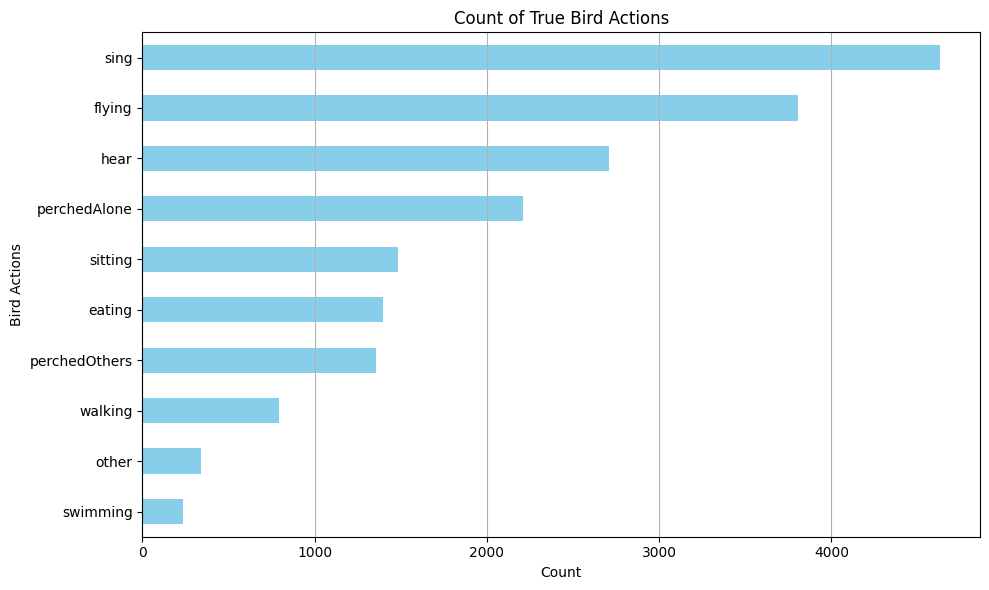

In [10]:
# Read the CSV file
df = pd.read_csv('export2.csv')

# Define the columns you want to count
bird_action_cols = ['flying', 'hear', 'perchedAlone', 'perchedOthers', 'sing', 'sitting', 'swimming', 'walking', 'other', 'eating']

# Count the number of True values for each bird action column
counts = df[bird_action_cols].sum()

# Plot the counts
plt.figure(figsize=(10, 6))
counts.sort_values().plot(kind='barh', color='skyblue')
plt.title('Count of True Bird Actions')
plt.xlabel('Count')
plt.ylabel('Bird Actions')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

In [11]:
# We create a dataframe with udid, observationTime (before, during, after), timeDiff, and actions ['flying', 'hear', 'perchedAlone', 'perchedOthers', 'sing', 'sitting', 'swimming', 'walking', 'other', 'eating']

DF = pd.read_csv('export2.csv')

# Create a list to store the observations
observations = []

# Iterate through each row in the DataFrame
for index, row in DF.iterrows():
    udid = row['udid']
    time_submit = pd.to_datetime(row['timeSubmit'])
    totality_begins = pd.to_datetime(row['totalityBegins'])
    totality_ends = pd.to_datetime(row['totalityEnds'])
    max_eclipse = pd.to_datetime(row['maxEclipse'])
    eclipseType = "total"

    if totality_begins.year != 2024: # for partial eclipse, totality_begins is set to 1990
      totality_begins = pd.to_datetime(row['eclipseBegins'])
      totality_ends = pd.to_datetime(row['eclipseEnds'])
      eclipseType = "partial"

    # Define observation time boundaries
    observation_start = totality_begins #- pd.Timedelta(minutes=0)
    observation_end = totality_ends #+ pd.Timedelta(minutes=0)

    # Check observation time
    if time_submit < observation_start:
        observation_time = 'before'
    elif time_submit >= observation_start and time_submit <= observation_end:
        observation_time = 'during'
    else:
        observation_time = 'after'

    # getting timeDiff: abs(time submit - max eclipse)
    # if we dont have time_submit or max_eclipse time for row, set timeDiff to nan
    if pd.isna(time_submit) or pd.isna(max_eclipse):
        timeDiff = np.nan
    else:
        timeDiff = abs(time_submit - max_eclipse)
    #timeDiff = abs(time_submit - max_eclipse)

    # Create a dictionary for each observation
    observation = {
        'udid': udid,
        'observationTime': observation_time,
        'timeDiff': timeDiff,
        'eclipseType': eclipseType,
        'maxEclipse': max_eclipse,
        'timeSubmit': time_submit,
        'totalBegins': totality_begins,
        'obscuration': row['obscuration'],
        'flying': row['flying'],
        'hear': row['hear'],
        'perchedAlone': row['perchedAlone'],
        'perchedOthers': row['perchedOthers'],
        'sing': row['sing'],
        'sitting': row['sitting'],
        'swimming': row['swimming'],
        'walking': row['walking'],
        'other': row['other'],
        'eating': row['eating']
    }

    # Append the observation to the list
    observations.append(observation)

# Create a new DataFrame from the observations list
observationsDF = pd.DataFrame(observations)

# Display the new DataFrame
observationsDF

,udid,observationTime,timeDiff,eclipseType,maxEclipse,timeSubmit,totalBegins,obscuration,flying,hear,perchedAlone,perchedOthers,sing,sitting,swimming,walking,other,eating
0,feefb6bbf8ad63ed,before,0 days 00:17:13.834015,total,2024-04-08 15:08:00,2024-04-08 14:50:46.165985,2024-04-08 15:06:00,1.0,False,False,False,False,False,True,False,False,False,True
1,9BCE8E1E-4804-4344-8ADC-7DFD394AE91C,after,0 days 00:14:37.013972,total,2024-04-08 15:06:00,2024-04-08 15:20:37.013972,2024-04-08 15:04:00,1.0,False,False,True,False,False,False,False,False,False,True
2,f1a08bcbb23d9168,before,0 days 00:05:07.444359,total,2024-04-08 15:06:00,2024-04-08 15:00:52.555641,2024-04-08 15:04:00,1.0,False,True,False,True,True,False,False,False,False,False
3,19365862-6BE1-457A-947E-809F9F9C11EF,before,0 days 00:05:02.107256,total,2024-04-08 13:34:00,2024-04-08 13:28:57.892744,2024-04-08 13:31:00,1.0,True,False,False,False,False,False,False,False,False,False
4,67759611a2f8dd94,after,0 days 00:04:12.030083,total,2024-04-08 15:14:00,2024-04-08 15:18:12.030083,2024-04-08 15:13:00,1.0,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10854,0863012E-243E-41C5-A756-498AF65622A3,before,0 days 00:18:21.943410,total,2024-04-08 15:09:00,2024-04-08 14:50:38.056590,2024-04-08 15:07:00,1.0,False,True,False,False,True,False,False,False,False,False
10855,9e186c42bfb0471b,before,0 days 00:06:49.790528,total,2024-04-08 15:16:00,2024-04-08 15:09:10.209472,2024-04-08 15:15:00,1.0,False,True,False,False,False,False,False,False,False,False
10856,88871BA6-7C02-40FC-8D63-7EF02AC40BEB,before,0 days 00:09:52.425393,total,2024-04-08 15:07:00,2024-04-08 14:57:07.574607,2024-04-08 15:05:00,1.0,True,False,True,False,False,False,False,False,False,False
10857,cdee1e8d13441b96,before,0 days 00:17:29.990356,total,2024-04-08 15:08:00,2024-04-08 14:50:30.009644,2024-04-08 15:06:00,1.0,True,False,True,False,True,False,False,False,False,False


In [12]:
# Sort observationsDF based on udid and observationTime
# Define custom sorting order for observationTime
custom_order = {'before': 0, 'during': 1, 'after': 2}

# Sort the DataFrame based on 'udid' and custom order of 'observationTime'
observationsDF['observationTime'] = observationsDF['observationTime'].map(custom_order)
observationsDF = observationsDF.sort_values(by=['udid', 'observationTime'])

# Reset the custom order for 'observationTime'
observationsDF['observationTime'] = observationsDF['observationTime'].map({v: k for k, v in custom_order.items()})

# Reset the index
observationsDF.reset_index(drop=True, inplace=True)

# Display the sorted DataFrame
observationsDF

,udid,observationTime,timeDiff,eclipseType,maxEclipse,timeSubmit,totalBegins,obscuration,flying,hear,perchedAlone,perchedOthers,sing,sitting,swimming,walking,other,eating
0,0022BC5E-BEF3-459E-A34B-C4FADAB415B8,during,0 days 00:00:48.833910,partial,2024-04-08 15:05:00,2024-04-08 15:04:11.166090,2024-04-08 13:47:00,0.825,False,False,True,False,True,True,False,False,False,False
1,0022BC5E-BEF3-459E-A34B-C4FADAB415B8,during,0 days 00:02:39.454378,partial,2024-04-08 15:05:00,2024-04-08 15:02:20.545622,2024-04-08 13:47:00,0.825,False,True,False,False,True,False,False,False,False,False
2,009A7715-A68F-4A42-998C-50EC13F86A8C,during,0 days 00:17:52.352412,partial,2024-04-08 15:00:00,2024-04-08 14:42:07.647588,2024-04-08 13:43:00,0.582,False,True,False,False,True,False,False,False,False,False
3,009A7715-A68F-4A42-998C-50EC13F86A8C,during,0 days 00:14:27.649367,partial,2024-04-08 15:00:00,2024-04-08 14:45:32.350633,2024-04-08 13:43:00,0.582,True,False,False,True,True,True,False,False,False,False
4,00A45886-B4B2-40AC-858F-103F9C7F0CF2,before,0 days 00:13:42.212315,total,2024-04-08 15:07:00,2024-04-08 14:53:17.787685,2024-04-08 15:06:00,1.000,True,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10854,NaN,after,NaT,partial,NaT,NaT,NaT,1.000,False,False,True,False,True,False,False,False,False,False
10855,NaN,after,NaT,partial,NaT,NaT,NaT,1.000,True,False,False,False,False,False,False,False,False,False
10856,NaN,after,NaT,partial,NaT,NaT,NaT,1.000,False,False,False,False,False,False,False,False,False,False
10857,NaN,after,NaT,partial,NaT,NaT,NaT,1.000,True,False,False,False,True,False,False,False,False,True


In [13]:
# Counts for observation times
# Count occurrences of "before", "during", and "after" in 'observationTime'
observation_counts = observationsDF['observationTime'].value_counts()
print(f"{observation_counts}")

# Count number of partial/total eclipse observations
eclipseType_counts = observationsDF['eclipseType'].value_counts()
print(f"{eclipseType_counts}")

observationTime
before    5766
after     2815
during    2278
Name: count, dtype: int64
eclipseType
total      8534
partial    2325
Name: count, dtype: int64


In [14]:
# Export and download observationsDF table as CSV
# Exporting to CSV file named 'observations.csv'
observationsDF.to_csv('observations.csv', index=False)

# if you want to download, set wantToDownload to be True, else (if already downloaded once), put False
wantToDownload = True
if (wantToDownload):
  # Downloading the CSV file
  from google.colab import files
  files.download('observations.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

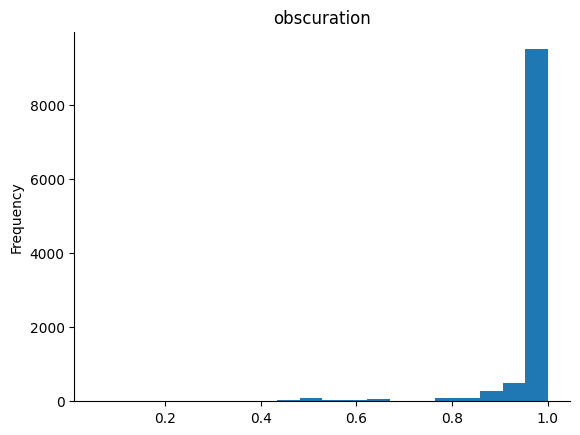

In [15]:
# plot histogram for obscuration
observationsDF['obscuration'].plot(kind='hist', bins=20, title='obscuration')
plt.gca().spines[['top', 'right',]].set_visible(False)

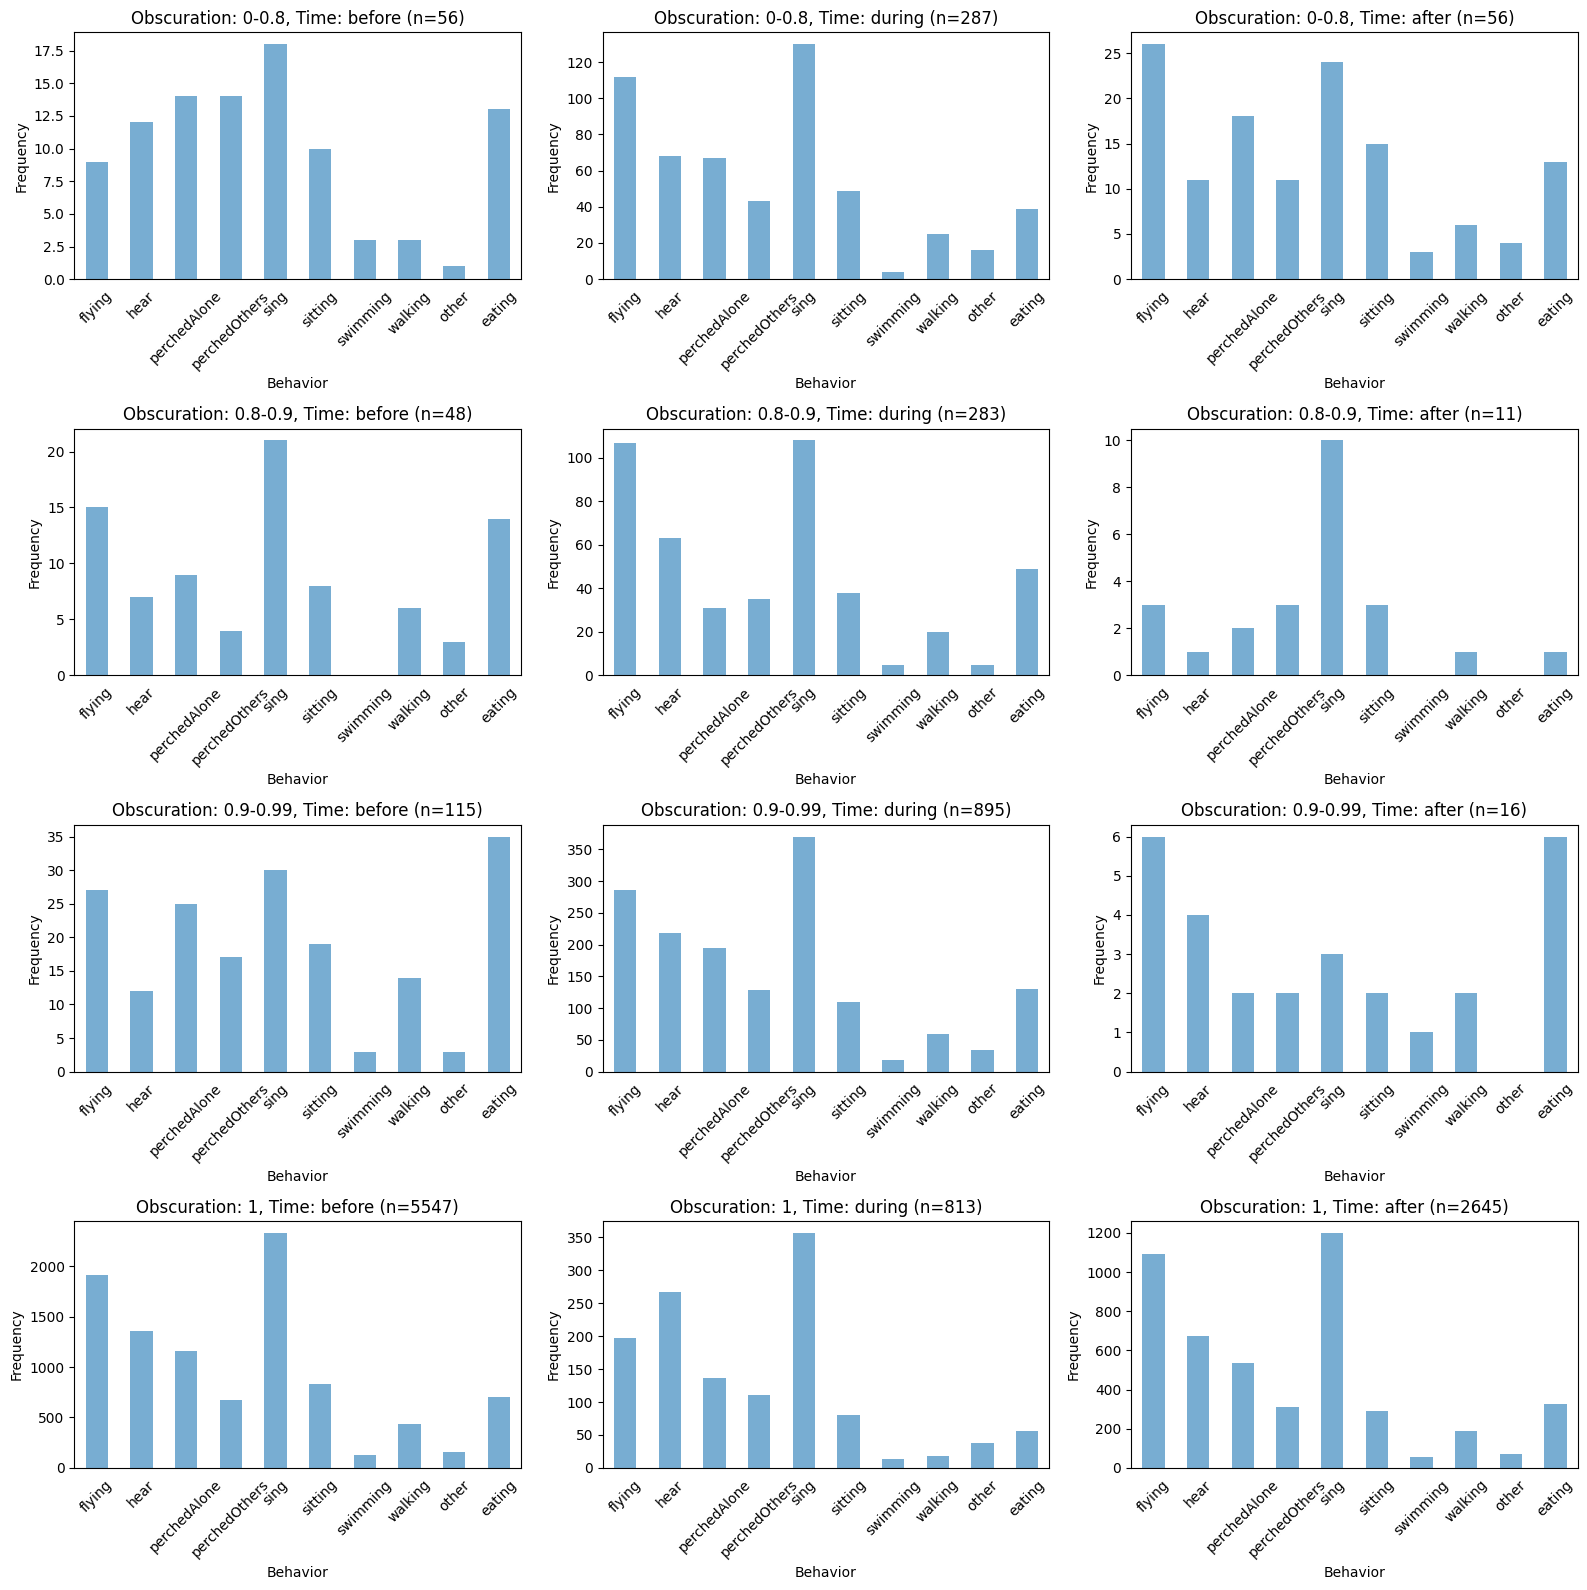

Total n = 10772


In [16]:
# Categorized into bins
# First, let's categorize the obscuration into different bins

# First, let's categorize the obscuration into different bins
observationsDF['obscuration_bins'] = pd.cut(observationsDF['obscuration'], bins=[0, 0.8, 0.9, 0.99, 1], labels=['0-0.8', '0.8-0.9', '0.9-0.99', '1'])

# Then, filter the dataframe for each obscuration bin and observation time
obscuration_bins = ['0-0.8', '0.8-0.9', '0.9-0.99', '1']
observation_times = ['before', 'during', 'after']

# Define behaviors
behaviors = ['flying', 'hear', 'perchedAlone', 'perchedOthers', 'sing', 'sitting', 'swimming', 'walking', 'other', 'eating']

total_sum = 0
# Create subplots
fig, axs = plt.subplots(len(obscuration_bins), 3, figsize=(16, 16))  # 3 rows, each row contains histograms for different observation times

for i, time_label in enumerate(observation_times):
    for j, bin_label in enumerate(obscuration_bins):
        obs_subset = observationsDF[(observationsDF['obscuration_bins'] == bin_label) & (observationsDF['observationTime'] == time_label)]
        obs_counts = obs_subset[behaviors].sum()
        obs_counts.plot(kind='bar', alpha=0.6, ax=axs[j,i])
        axs[j,i].set_title(f'Obscuration: {bin_label}, Time: {time_label} (n={len(obs_subset)})')
        axs[j,i].set_xlabel('Behavior')
        axs[j,i].set_ylabel('Frequency')
        axs[j,i].set_xticklabels(behaviors, rotation=45)
        axs[j,i].tick_params(axis='x', which='both', bottom=False, top=False)  # Hide ticks on x-axis
        total_sum += len(obs_subset)

plt.tight_layout()
plt.show()

print(f"Total n = {total_sum}")

In [17]:
observationsDF

,udid,observationTime,timeDiff,eclipseType,maxEclipse,timeSubmit,totalBegins,obscuration,flying,hear,perchedAlone,perchedOthers,sing,sitting,swimming,walking,other,eating,obscuration_bins
0,0022BC5E-BEF3-459E-A34B-C4FADAB415B8,during,0 days 00:00:48.833910,partial,2024-04-08 15:05:00,2024-04-08 15:04:11.166090,2024-04-08 13:47:00,0.825,False,False,True,False,True,True,False,False,False,False,0.8-0.9
1,0022BC5E-BEF3-459E-A34B-C4FADAB415B8,during,0 days 00:02:39.454378,partial,2024-04-08 15:05:00,2024-04-08 15:02:20.545622,2024-04-08 13:47:00,0.825,False,True,False,False,True,False,False,False,False,False,0.8-0.9
2,009A7715-A68F-4A42-998C-50EC13F86A8C,during,0 days 00:17:52.352412,partial,2024-04-08 15:00:00,2024-04-08 14:42:07.647588,2024-04-08 13:43:00,0.582,False,True,False,False,True,False,False,False,False,False,0-0.8
3,009A7715-A68F-4A42-998C-50EC13F86A8C,during,0 days 00:14:27.649367,partial,2024-04-08 15:00:00,2024-04-08 14:45:32.350633,2024-04-08 13:43:00,0.582,True,False,False,True,True,True,False,False,False,False,0-0.8
4,00A45886-B4B2-40AC-858F-103F9C7F0CF2,before,0 days 00:13:42.212315,total,2024-04-08 15:07:00,2024-04-08 14:53:17.787685,2024-04-08 15:06:00,1.000,True,False,False,False,False,False,True,False,False,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10854,NaN,after,NaT,partial,NaT,NaT,NaT,1.000,False,False,True,False,True,False,False,False,False,False,1
10855,NaN,after,NaT,partial,NaT,NaT,NaT,1.000,True,False,False,False,False,False,False,False,False,False,1
10856,NaN,after,NaT,partial,NaT,NaT,NaT,1.000,False,False,False,False,False,False,False,False,False,False,1
10857,NaN,after,NaT,partial,NaT,NaT,NaT,1.000,True,False,False,False,True,False,False,False,False,True,1


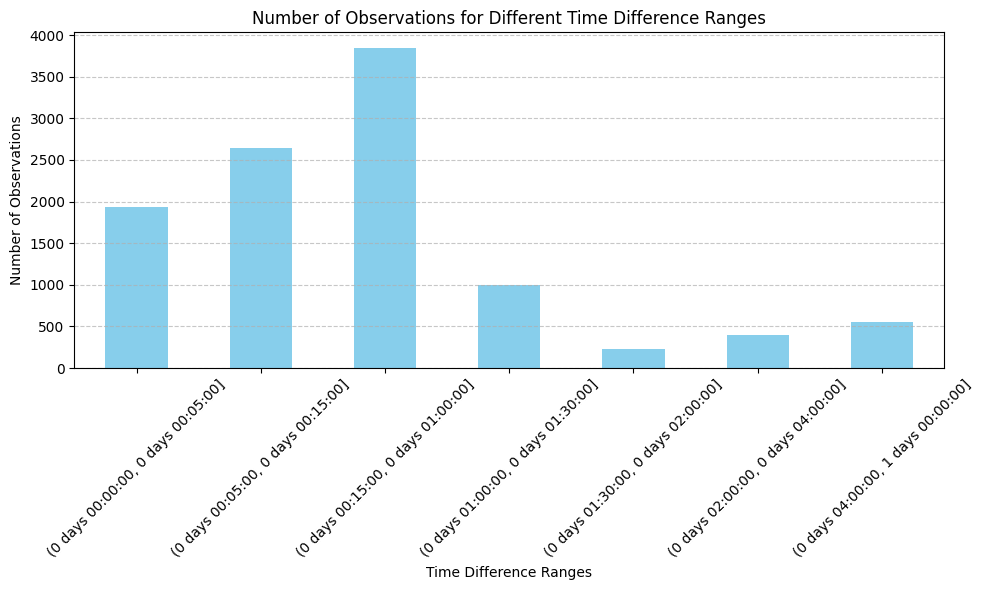

In [18]:
# Creating histogram for number of observations per time range for timeDiff
# Define bins/ranges for timeDiff
bins = [pd.Timedelta(minutes=0), pd.Timedelta(minutes=5), pd.Timedelta(minutes=15), pd.Timedelta(hours=1), pd.Timedelta(hours=1.5), pd.Timedelta(hours=2), pd.Timedelta(hours=4), pd.Timedelta(hours=24)]

# Group observations into bins based on timeDiff
observationsDF['timeDiff_bins'] = pd.cut(observationsDF['timeDiff'], bins=bins)

# Count the number of observations in each bin
observations_count = observationsDF['timeDiff_bins'].value_counts().sort_index()

# Plot the results
plt.figure(figsize=(10, 6))
observations_count.plot(kind='bar', color='skyblue')
plt.title('Number of Observations for Different Time Difference Ranges')
plt.xlabel('Time Difference Ranges')
plt.ylabel('Number of Observations')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [19]:
# Count rows with abs(timeDiff) > 1 day
count_greater_than_1_day = len(observationsDF[(observationsDF['timeDiff']) > pd.Timedelta(days=1)])

# Count rows with abs(timeDiff) > 4 hour
count_greater_than_4_hour = len(observationsDF[(observationsDF['timeDiff']) > pd.Timedelta(hours=4)])

# Count rows with abs(timeDiff) > 1 hour
count_greater_than_1_hour = len(observationsDF[(observationsDF['timeDiff']) > pd.Timedelta(hours=1)])

# Count rows with abs(timeDiff) > 10 minutes
count_greater_than_10_mins = len(observationsDF[(observationsDF['timeDiff']) > pd.Timedelta(minutes=10)])

# Count rows with abs(timeDiff) < 1 minute
count_less_than_1_min = len(observationsDF[(observationsDF['timeDiff']) < pd.Timedelta(minutes=1)])

print("Number of rows with abs(timeDiff) > 1 day:", count_greater_than_1_day)
print("Number of rows with abs(timeDiff) > 4 hour:", count_greater_than_4_hour)
print("Number of rows with abs(timeDiff) > 1 hour:", count_greater_than_1_hour)
print("Number of rows with abs(timeDiff) > 10 minutes:", count_greater_than_10_mins)
print("Number of rows with abs(timeDiff) < 1 minute:", count_less_than_1_min)

Number of rows with abs(timeDiff) > 1 day: 85
Number of rows with abs(timeDiff) > 4 hour: 641
Number of rows with abs(timeDiff) > 1 hour: 2272
Number of rows with abs(timeDiff) > 10 minutes: 7199
Number of rows with abs(timeDiff) < 1 minute: 409


In [20]:
# Dealing with duplicate observations
# We condense duplicate observations, i.e observations with same udid, observationTime (before,during,after) and bird behaviors, and we average out the timeDiff
# Define the criteria for identifying duplicate submissions
criteria_columns = ['udid', 'observationTime', 'flying', 'hear', 'perchedAlone', 'perchedOthers', 'sing', 'sitting', 'swimming', 'walking', 'other', 'eating']

# Find duplicate submissions based on the specified criteria
duplicates = observationsDF.duplicated(subset=criteria_columns, keep=False)

# Group duplicate submissions by the criteria and calculate the average timeDiff
duplicate_groups = observationsDF[duplicates].groupby(criteria_columns)
average_timeDiff = duplicate_groups['timeDiff'].mean()

# Update the timeDiff for duplicate submissions with the average timeDiff
filtered_observationsDF = observationsDF
filtered_observationsDF.loc[duplicates, 'timeDiff'] = observationsDF[duplicates].set_index(criteria_columns).index.map(average_timeDiff)

# Drop duplicate rows
filtered_observationsDF.drop_duplicates(subset=criteria_columns, keep='first', inplace=True)

filtered_observationsDF

,udid,observationTime,timeDiff,eclipseType,maxEclipse,timeSubmit,totalBegins,obscuration,flying,hear,perchedAlone,perchedOthers,sing,sitting,swimming,walking,other,eating,obscuration_bins,timeDiff_bins
0,0022BC5E-BEF3-459E-A34B-C4FADAB415B8,during,0 days 00:00:48.833910,partial,2024-04-08 15:05:00,2024-04-08 15:04:11.166090,2024-04-08 13:47:00,0.825,False,False,True,False,True,True,False,False,False,False,0.8-0.9,"(0 days 00:00:00, 0 days 00:05:00]"
1,0022BC5E-BEF3-459E-A34B-C4FADAB415B8,during,0 days 00:02:39.454378,partial,2024-04-08 15:05:00,2024-04-08 15:02:20.545622,2024-04-08 13:47:00,0.825,False,True,False,False,True,False,False,False,False,False,0.8-0.9,"(0 days 00:00:00, 0 days 00:05:00]"
2,009A7715-A68F-4A42-998C-50EC13F86A8C,during,0 days 00:17:52.352412,partial,2024-04-08 15:00:00,2024-04-08 14:42:07.647588,2024-04-08 13:43:00,0.582,False,True,False,False,True,False,False,False,False,False,0-0.8,"(0 days 00:15:00, 0 days 01:00:00]"
3,009A7715-A68F-4A42-998C-50EC13F86A8C,during,0 days 00:14:27.649367,partial,2024-04-08 15:00:00,2024-04-08 14:45:32.350633,2024-04-08 13:43:00,0.582,True,False,False,True,True,True,False,False,False,False,0-0.8,"(0 days 00:05:00, 0 days 00:15:00]"
4,00A45886-B4B2-40AC-858F-103F9C7F0CF2,before,0 days 00:13:42.212315,total,2024-04-08 15:07:00,2024-04-08 14:53:17.787685,2024-04-08 15:06:00,1.000,True,False,False,False,False,False,True,False,False,False,1,"(0 days 00:05:00, 0 days 00:15:00]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10839,NaN,after,NaT,partial,NaT,NaT,NaT,1.000,True,True,False,False,False,False,False,False,False,False,1,NaN
10849,NaN,after,NaT,partial,NaT,NaT,NaT,1.000,True,True,True,False,False,False,False,False,False,False,1,NaN
10850,NaN,after,NaT,partial,NaT,NaT,NaT,1.000,True,True,True,False,True,True,False,True,False,False,1,NaN
10853,NaN,after,NaT,partial,NaT,NaT,NaT,0.997,False,False,False,False,True,True,False,False,False,False,1,NaN


In [21]:
# Removing observations that go above threshold of 4 hours before or after maxEclipse (threshold can be changed)
# Define the threshold for timeDiff
threshold = pd.Timedelta(hours=4)

# Filter observations where timeDiff is within the threshold
filtered_observationsDF2 = filtered_observationsDF[abs(filtered_observationsDF['timeDiff']) <= threshold]

# Print the number of rows removed
rows_removed = len(filtered_observationsDF) - len(filtered_observationsDF2)
print("Number of rows removed:", rows_removed)

# Display the filtered DataFrame
filtered_observationsDF2

Number of rows removed: 637


,udid,observationTime,timeDiff,eclipseType,maxEclipse,timeSubmit,totalBegins,obscuration,flying,hear,perchedAlone,perchedOthers,sing,sitting,swimming,walking,other,eating,obscuration_bins,timeDiff_bins
0,0022BC5E-BEF3-459E-A34B-C4FADAB415B8,during,0 days 00:00:48.833910,partial,2024-04-08 15:05:00,2024-04-08 15:04:11.166090,2024-04-08 13:47:00,0.825,False,False,True,False,True,True,False,False,False,False,0.8-0.9,"(0 days 00:00:00, 0 days 00:05:00]"
1,0022BC5E-BEF3-459E-A34B-C4FADAB415B8,during,0 days 00:02:39.454378,partial,2024-04-08 15:05:00,2024-04-08 15:02:20.545622,2024-04-08 13:47:00,0.825,False,True,False,False,True,False,False,False,False,False,0.8-0.9,"(0 days 00:00:00, 0 days 00:05:00]"
2,009A7715-A68F-4A42-998C-50EC13F86A8C,during,0 days 00:17:52.352412,partial,2024-04-08 15:00:00,2024-04-08 14:42:07.647588,2024-04-08 13:43:00,0.582,False,True,False,False,True,False,False,False,False,False,0-0.8,"(0 days 00:15:00, 0 days 01:00:00]"
3,009A7715-A68F-4A42-998C-50EC13F86A8C,during,0 days 00:14:27.649367,partial,2024-04-08 15:00:00,2024-04-08 14:45:32.350633,2024-04-08 13:43:00,0.582,True,False,False,True,True,True,False,False,False,False,0-0.8,"(0 days 00:05:00, 0 days 00:15:00]"
4,00A45886-B4B2-40AC-858F-103F9C7F0CF2,before,0 days 00:13:42.212315,total,2024-04-08 15:07:00,2024-04-08 14:53:17.787685,2024-04-08 15:06:00,1.000,True,False,False,False,False,False,True,False,False,False,1,"(0 days 00:05:00, 0 days 00:15:00]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10748,ff99c482ac94b926,after,0 days 00:09:01.869657666,total,2024-04-08 15:07:00,2024-04-08 15:17:25.539340,2024-04-08 15:05:00,1.000,False,False,False,False,True,False,False,False,False,False,1,"(0 days 00:05:00, 0 days 00:15:00]"
10751,fff42ef2f69d9260,before,0 days 00:16:41.134348,total,2024-04-08 15:10:00,2024-04-08 14:53:18.865652,2024-04-08 15:08:00,1.000,False,False,False,False,True,False,False,False,False,False,1,"(0 days 00:15:00, 0 days 01:00:00]"
10752,fff42ef2f69d9260,before,0 days 00:23:20.643762,total,2024-04-08 15:10:00,2024-04-08 14:46:39.356238,2024-04-08 15:08:00,1.000,False,True,False,False,True,False,False,False,False,False,1,"(0 days 00:15:00, 0 days 01:00:00]"
10753,fff42ef2f69d9260,during,0 days 00:00:03.246330,total,2024-04-08 15:10:00,2024-04-08 15:10:03.246330,2024-04-08 15:08:00,1.000,False,False,False,False,True,False,False,False,False,False,1,"(0 days 00:00:00, 0 days 00:05:00]"


<ipython-input-22-d7c53de12ec7>:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



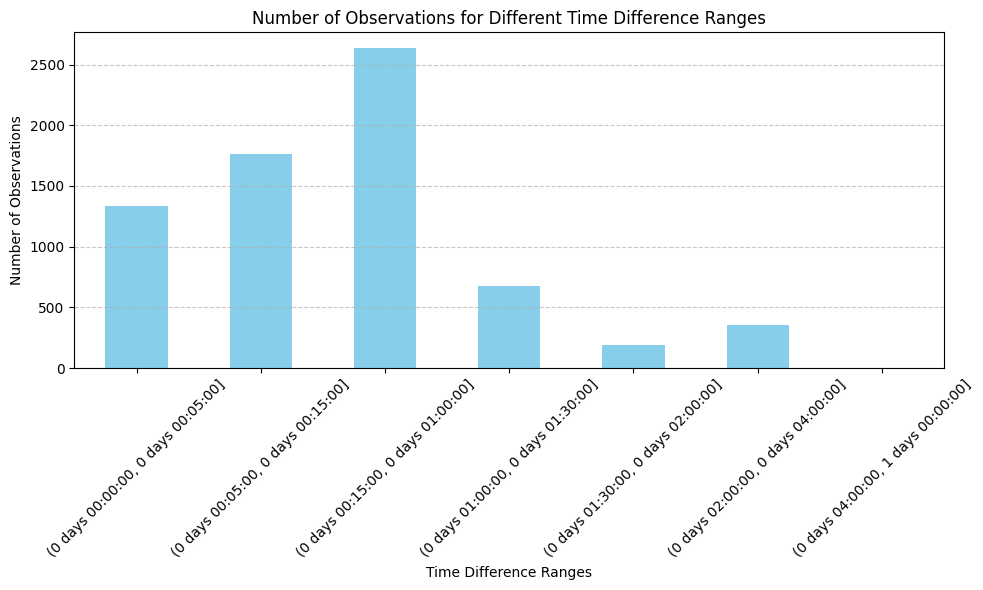

In [22]:
# Creating histogram for number of observations per time range for timeDiff
# Define bins/ranges for timeDiff
bins = [pd.Timedelta(minutes=0), pd.Timedelta(minutes=5), pd.Timedelta(minutes=15), pd.Timedelta(hours=1), pd.Timedelta(hours=1.5), pd.Timedelta(hours=2), pd.Timedelta(hours=4), pd.Timedelta(hours=24)]

# Group observations into bins based on timeDiff
filtered_observationsDF2['timeDiff_bins'] = pd.cut(filtered_observationsDF2['timeDiff'], bins=bins)

# Count the number of observations in each bin
observations_count = filtered_observationsDF2['timeDiff_bins'].value_counts().sort_index()

# Plot the results
plt.figure(figsize=(10, 6))
observations_count.plot(kind='bar', color='skyblue')
plt.title('Number of Observations for Different Time Difference Ranges')
plt.xlabel('Time Difference Ranges')
plt.ylabel('Number of Observations')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [23]:
# Export and download filtered_observationsDF2 table as CSV
# Exporting to CSV file named 'observations.csv'
filtered_observationsDF2.to_csv('filtered_observations.csv', index=False)

# if you want to download, set wantToDownload to be True, else (if already downloaded once), put False
wantToDownload = True
if (wantToDownload):
  # Downloading the CSV file
  from google.colab import files
  files.download('filtered_observations.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>